In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

import ray
import torch
from torch.utils.data import DataLoader
import pytorch_lightning as pl
from numpy.random import default_rng
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.loggers import WandbLogger
import wandb

import matplotlib.pyplot as plt
import numpy as np

In [3]:
import sys
sys.path.append("../")
sys.path.append("../../recurrently_predicting_hypergraphs/")

from convex_hull_dataset import get_ch_dl, ConvexHullData
import misc
import metrics

In [4]:
# Dataset
D_FEATS = 3
N_POINTS = torch.arange(30,31)
UNIT_NORM = False
ADD_INDICATOR = True

# Model hyperparameter
CONFIG = "../configs/hgflow.yaml"
TRAIN = "../configs/train.yaml"

# Training hyperparameter
BATCH_SIZE = 64
LR = 0.0003
N_EPOCHS = 1000

# Miscellaneous
SEED = 123456
RNG = default_rng(SEED)
pl.seed_everything(SEED)
N_RAY = 0
if N_RAY > 0:
    ray.init(num_cpus=N_RAY,include_dashboard=False)

Global seed set to 123456


In [5]:
def get_collate_fn(max_facets, add_indicator=False, max_points=None, do_randomize=False):

    if do_randomize:
        print("Warning: randomizing the incidence matrix!")

    def pad(x, max_points, pad_value=float('nan')):
        if max_points is None:
            return x
        delta = max_points - x.size(0)
        if delta > 0:
            x = torch.cat([x, torch.full((delta, x.size(1)), pad_value)], dim=0)
        elif delta < 0:
            raise ValueError("max_points is smaller than the number of points!")
        return x
    
    def randomize(i):
        if not do_randomize:
            return i
        mask = torch.randint(0, 2, (i.shape[0], i.shape[1]), dtype=torch.bool)
        std = 0.01
        mean = 0.5
        out = mask*(std*torch.randn_like(i) - mean) + (~mask)*(std*torch.randn_like(i) + mean)
        return out

    if not add_indicator:
        def collate_fn(batch):
            points = []
            incidence = []
            for p, i in batch:
                points.append(pad(p, max_points))
                inc = torch.cat([i, torch.zeros(max_facets - i.size(0), i.size(1))],dim=0)
                inc = pad(inc, max_facets, pad_value=0)
                inc = randomize(inc)
                incidence.append(inc)
            return torch.stack(points), torch.stack(incidence)
        return collate_fn
    else:
        def collate_fn(batch):
            points = []
            incidence = []
            for p, i in batch:
                points.append(pad(p, max_points))
                nf = i.size(0)
                inc = torch.cat([i, torch.zeros(max_facets - nf, i.size(1))],dim=0)
                inc = torch.cat([inc, torch.zeros(max_facets, 1)], dim=1)
                inc[:nf,-1] = 1.
                inc = pad(inc, max_facets, pad_value=0)
                inc = randomize(inc)
                incidence.append(inc)
            return torch.stack(points), torch.stack(incidence)
        return collate_fn

In [6]:
train_dataset = ConvexHullData(n_range=N_POINTS,dim=D_FEATS,unit_norm=UNIT_NORM,length=20000)
assert train_dataset.max_facets <= 42, "max facets should be smaller than 40, got {}".format(train_dataset.max_facets)
collate_fn = get_collate_fn(max_facets=max(train_dataset.max_facets, 42), add_indicator=ADD_INDICATOR, max_points=train_dataset.max_points, do_randomize=False)
# train_dataset = torch.utils.data.Subset(train_dataset, torch.arange(0, 50)) #HACK
trainloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, collate_fn=collate_fn, shuffle=False, num_workers=0)

In [7]:
# train_dataset = ConvexHullData(n_range=N_POINTS,dim=D_FEATS,unit_norm=UNIT_NORM,length=20000)
# collate_fn = get_collate_fn(max_facets=train_dataset.max_facets, add_indicator=ADD_INDICATOR, max_points=train_dataset.max_points, do_randomize=False)
# trainloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, collate_fn=collate_fn, shuffle=True, num_workers=0)

In [8]:
val_dataset = ConvexHullData(n_range=N_POINTS,dim=D_FEATS,unit_norm=UNIT_NORM,length=2000)#256)
assert val_dataset.max_facets <= 42, "max facets should be smaller than 40, got {}".format(val_dataset.max_facets)
valloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, collate_fn=collate_fn, shuffle=False, num_workers=0)

In [9]:
for example in valloader:
    x, y  = example
    break

In [10]:
x = x[0]
y = y[0]

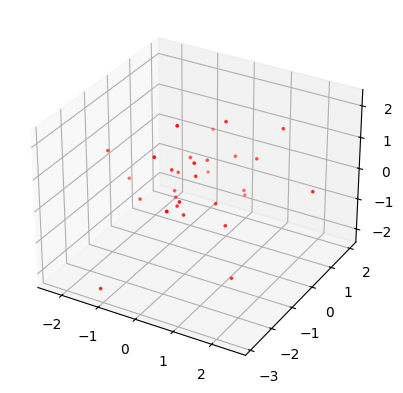

In [11]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x[:, 0], x[:, 1], x[:, 2], s=3, c='r', marker='o')
plt.show()

In [12]:
y[:,-1]

tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0.])

In [13]:
print("Number of hyperedges per point:")
print(y[:,:-1].sum(axis=0))
print("Number of points per hyperedge:")
print(y[:,:-1].sum(axis=1))

Number of hyperedges per point:
tensor([5., 0., 0., 5., 7., 0., 3., 0., 4., 0., 0., 3., 0., 0., 0., 5., 0., 0.,
        0., 4., 7., 0., 5., 0., 0., 5., 0., 0., 6., 7.])
Number of points per hyperedge:
tensor([3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
        3., 3., 3., 3., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0.])


In [14]:
def plot_incidence_matrix(im, inverted=True):
    fig, ax = plt.subplots()
    if inverted:
        im = 1 - im
    ax.imshow(im, cmap='hot', vmin=0, vmax=1)
    ax.set_ylabel("Hyperedge")
    ax.set_xlabel("Vertex")
    plt.show()

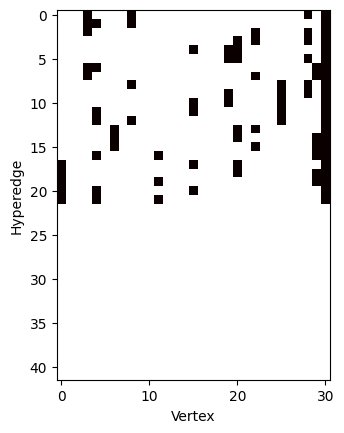

In [15]:
plot_incidence_matrix(y)

In [16]:
from lights.hgflow_lightning import HGFlowLightning

In [17]:
model = HGFlowLightning(
    model_config=CONFIG,
    train_config=TRAIN,
)

In [18]:
data_type = "spherical" if UNIT_NORM else "normal"
wandb.init(
    settings=wandb.Settings(start_method='spawn'),
    name=f"{model.name} P{N_POINTS[0]}to{N_POINTS[-1]}",
    project=f"log_convex_hull_{data_type}",
    reinit=False,
)
logger = WandbLogger(
    log_model=True,
)
checkpoint_callback = ModelCheckpoint(
    monitor='loss/val',
    mode='min',
)

wandb: Currently logged in as: etienne-dreyer (etienne-dreyer-weizmann-institute-of-science) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


/Users/ets/miniconda3/envs/torchmetal/lib/python3.12/site-packages/pytorch_lightning/loggers/wandb.py:395: UserWarning: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
  rank_zero_warn(


In [ ]:
trainer = pl.Trainer(
    accelerator="mps",
    devices=1,
    max_epochs=20,
    check_val_every_n_epoch=1,
    logger=logger,
    callbacks=[checkpoint_callback],
)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [21]:
trainer.fit(model, trainloader, valloader)
# trainer.fit(model, trainloader, trainloader)


  | Name | Type   | Params
--------------------------------
0 | net  | HGFlow | 174 K 
--------------------------------
174 K     Trainable params
0         Non-trainable params
174 K     Total params
0.700     Total estimated model params size (MB)


Sanity Checking: 0it [00:00, ?it/s]

/Users/ets/miniconda3/envs/torchmetal/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:224: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 8 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Training: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

...

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.


In [22]:
for batch in trainloader:
    break

In [23]:
bs, num_edges, num_nodes = batch[1].shape
im_0 = model.net.get_init_im(bs, num_edges, num_nodes, device=batch[1].device)
if model.FM is not None:
    im_1, seq = model.sample(im_0, batch[0], save_seq=True)
    im_1 = im_1 * batch[1][:,:,-1:]
    # im_1[:,:,-1] = batch[1][:,:,-1]
else:
    im_1 = model.net.forward(im_0, batch[0], t=None).detach()

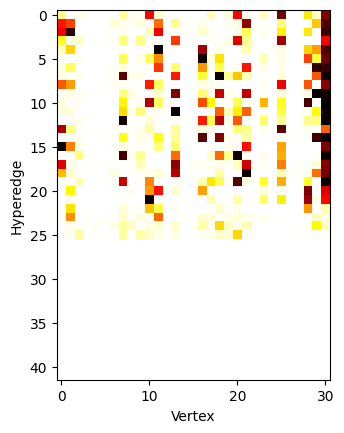

In [24]:
plot_incidence_matrix(im_1[0], inverted=True)

In [25]:
def convert_to_binary(im, threshold=0.5):
    return torch.where(im > threshold, 1, 0)

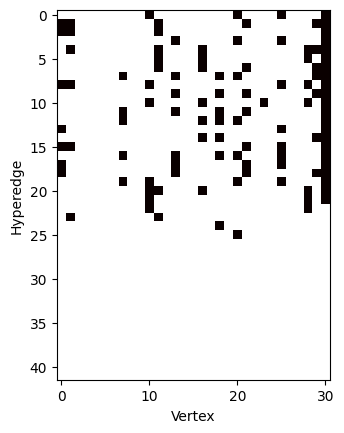

In [32]:
plot_incidence_matrix(convert_to_binary(im_1[0], threshold=0.3).cpu().numpy(), inverted=True)

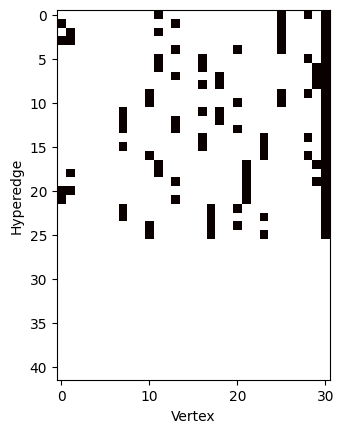

In [27]:
plot_incidence_matrix(batch[1][0].cpu().numpy(), inverted=True)

In [28]:
from metrics import LAP_loss
import numpy as np

def shuffle_incidence_matrix(im_pred, im_true):

    loss, indices = LAP_loss(im_pred, im_true, return_indices=True, loss_fn=torch.nn.functional.mse_loss)
    indices = torch.from_numpy(indices[:,1,...])
    indices = indices.unsqueeze(-1).expand(-1, -1, im_pred.shape[2])

    im_pred_shuffled = torch.gather(im_pred, 1, indices)

    return im_pred_shuffled, indices

In [29]:
im_pred_shuffled, indices = shuffle_incidence_matrix(im_1.clamp(0,1), batch[1])

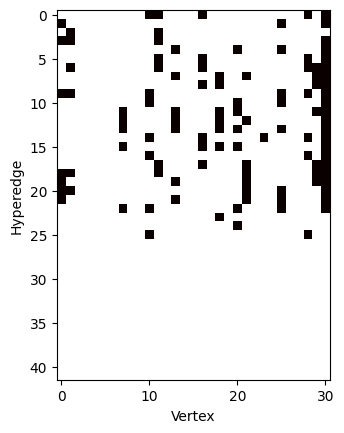

In [39]:
plot_incidence_matrix(convert_to_binary(im_pred_shuffled[0], threshold=0.3).cpu().detach().numpy(), inverted=True)

In [34]:
from lights.hgflow_lightning import transform_im

n, im_truth = batch
bs, num_edges, num_nodes = im_truth.shape
im_0 = model.net.get_init_im(bs, num_edges, num_nodes, n.device)

if model.FM is not None:
    h_exists_mask = im_truth[:,:,-1] > 0
    t, im_t = model.sample_location_and_conditional_flow(transform_im(im_truth, forward=True))
    im_t = torch.clamp(transform_im(im_t, forward=False), 0, 1)
    pred = model.net(im_t, t=t, n=n)
    loss = model.loss(pred, im_truth) #, mask=h_exists_mask)

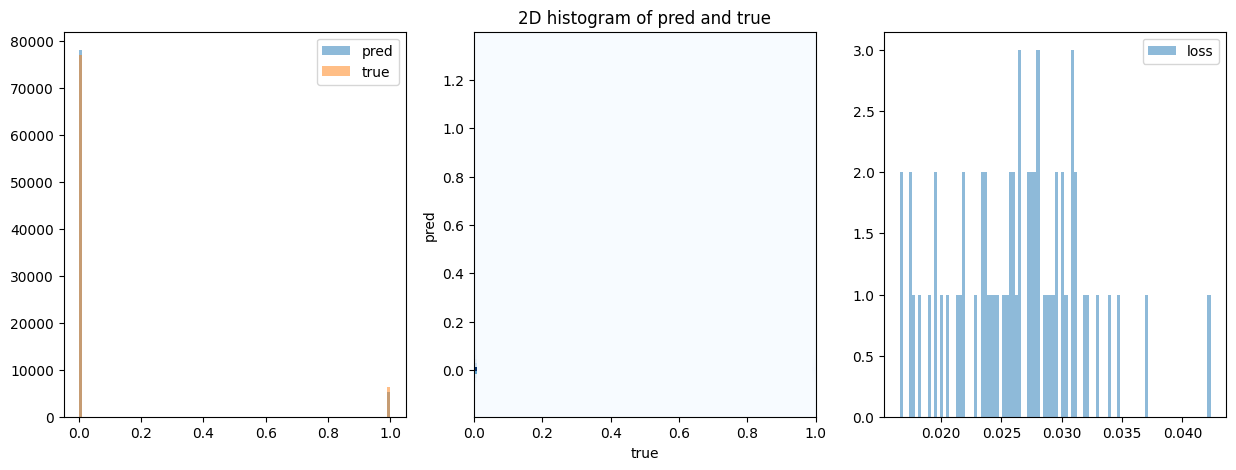

In [35]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].hist((pred.flatten().detach().cpu().numpy() > 0.5).astype(float), bins=100, alpha=0.5, label='pred')
ax[0].hist(im_truth.flatten().detach().cpu().numpy(), bins=100, alpha=0.5, label='true')
ax[0].legend()

ax[1].hist2d(im_truth.flatten().detach().cpu().numpy(), pred.flatten().detach().cpu().numpy(), bins=100, cmap='Blues')
ax[1].set_xlabel('true')
ax[1].set_ylabel('pred')
ax[1].set_title('2D histogram of pred and true')

ax[2].hist(loss.flatten().detach().cpu().numpy(), bins=100, alpha=0.5, label='loss')
ax[2].legend()

plt.show()


In [36]:
ts = []
im_ts = []
u_ts = []
u_ts_pred = []

for _ in range(20):

    t, im_t = model.sample_location_and_conditional_flow(transform_im(im_truth, forward=True))
    ts.append(t)
    im_ts.append(im_t)
    u_ts.append(im_truth)

    u_ts_pred.append(model.net(im_t, t=t, n=n))

ts = torch.stack(ts)
im_ts = torch.stack(im_ts)
u_ts = torch.stack(u_ts)
u_ts_pred = torch.stack(u_ts_pred)

sorted_indices = torch.argsort(ts, dim=0)
ts = torch.gather(ts, 0, sorted_indices)
im_ts = torch.gather(im_ts, 0, sorted_indices.unsqueeze(-1).unsqueeze(-1).expand(-1, -1, im_ts.shape[2], im_ts.shape[3]))
u_ts = torch.gather(u_ts, 0, sorted_indices.unsqueeze(-1).unsqueeze(-1).expand(-1, -1, u_ts.shape[2], u_ts.shape[3]))
u_ts_pred = torch.gather(u_ts_pred, 0, sorted_indices.unsqueeze(-1).unsqueeze(-1).expand(-1, -1, u_ts_pred.shape[2], u_ts_pred.shape[3]))

ts = ts.permute(1, 0)
im_ts = im_ts.permute(1, 0, 2, 3)
u_ts = u_ts.permute(1, 0, 2, 3)
u_ts_pred = u_ts_pred.permute(1, 0, 2, 3)

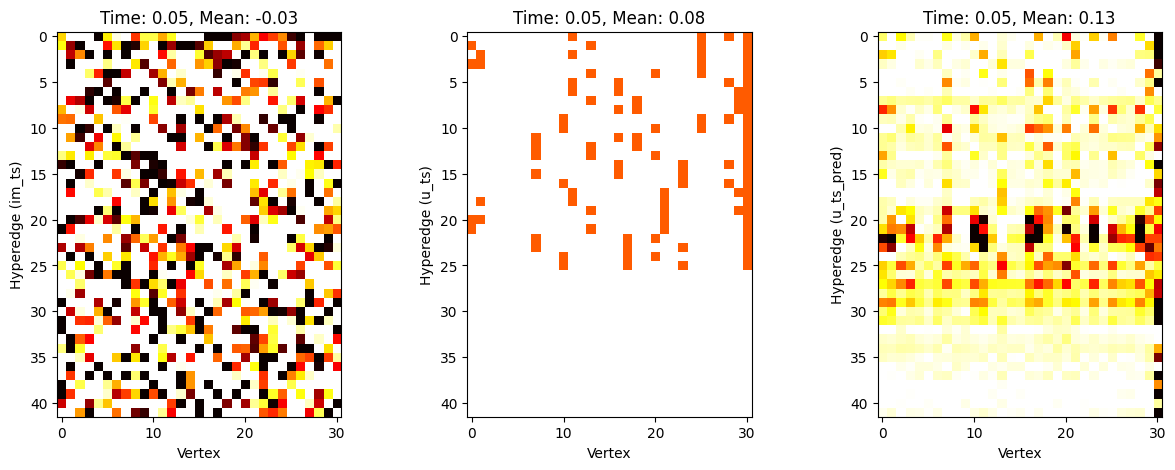

In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
ax1, ax2, ax3 = axes
b = 0

def update(timestep):
    ax1.clear()
    ax2.clear()
    ax3.clear()
    
    # Plot im_ts on the first axis
    im = im_ts[0][timestep].cpu().detach().numpy()
    ax1.imshow(1 - im, cmap='hot', vmin=0, vmax=1)  # Inverted for better visualization with normalized color axis
    ax1.set_title(f"Time: {ts[b][timestep].item():.2f}, Mean: {im.mean():.2f}")
    ax1.set_ylabel("Hyperedge (im_ts)")
    ax1.set_xlabel("Vertex")
    
    # Plot u_ts on the second axis
    u = u_ts[b][timestep].cpu().detach().numpy()
    ax2.imshow(1 - u, cmap='hot', vmin=-1, vmax=1)  # Inverted for better visualization
    ax2.set_ylabel("Hyperedge (u_ts)")
    ax2.set_title(f"Time: {ts[b][timestep].item():.2f}, Mean: {u.mean():.2f}")
    ax2.set_xlabel("Vertex")

    # Plot u_ts_pred on the third axis
    u_pred = u_ts_pred[b][timestep].cpu().detach().numpy()
    ax3.imshow(1 - u_pred, cmap='hot', vmin=-1, vmax=1)  # Inverted for better visualization
    ax3.set_ylabel("Hyperedge (u_ts_pred)")
    ax3.set_title(f"Time: {ts[b][timestep].item():.2f}, Mean: {u_pred.mean():.2f}")
    ax3.set_xlabel("Vertex")

ani = FuncAnimation(fig, update, frames=ts.shape[1], interval=500)

# Convert the animation to HTML
HTML(ani.to_jshtml())